In [16]:
import numpy as np
import pandas as pd
from skopt import gp_minimize
from skopt.space import Real, Integer
from skopt.plots import plot_convergence

In [34]:
def pacejka(P, FZ, IA, alpha):
    dfz = (FZ - P[0]) / P[0]
    Svy = FZ * (P[15] + P[16] * dfz + (P[17] + P[18] * dfz) * IA)
    Ey = (P[5] + P[6] * dfz) * (1 - (P[7] + P[8] * IA) * np.sign(alpha))
    Shy = (P[12] + P[13] * dfz + P[14] * IA)
    alphaY = alpha + Shy
    Cy = P[1]
    Dy = FZ * (P[2] + P[3] * dfz) * (1 - P[4] * IA**2)
    x1 = 2 * np.arctan(FZ / (P[10] * P[0]))
    x2 = P[9] * P[0] * np.sin(x1) * (1 - P[11] * np.abs(IA))
    By = x2 / (Cy * Dy)

    x3 = By * alphaY
    FY = Dy * np.sin(Cy * np.arctan(x3 - Ey * (x3 - np.arctan(x3)))) + Svy

    return FY

#want to minimize the difference between the measured and calculated cornering force values
def diffPacejka(P):
    df = pd.read_csv("C:/Users/ajsau/Downloads/R20_FZ_250_filtered.csv")
    FZ = df["NormalForce"]
    IA = df["InclinationAngle"]
    alpha = df["SlipAngle"]
    FY_measured = df["LateralForce"]
    FY_calculated = pacejka(P, FZ, IA, alpha)
    #must return a scalar, so return the average difference between calculated and measured
    FY_diff_total = 0
    for i in range(len(FY_measured)):
        FY_diff_total += abs(FY_calculated[i] - FY_measured[i])
    return FY_diff_total / len(FY_measured)

def remove_small_data(P):
    for i in range(len(P)):
        if abs(P[i]) < 1e-10:
            P[i] = 0

Best parameters: [250.01054942598302, -1.7386171806835868, -11.262382511326654, -3.339602085185348, 15.331210356754738, -7.026199159789039, -15.116481811973065, 0, 0, -45.57355012307293, 5.907604821654498, -19.979184920187368, 0, 0, -13.41376587428233, 0, 0, 0, -9.22350664805914]
Previous parameters: [250, 1.4, 2.4, -0.25, 3, -0.1, -1.5, 0, 0, -30.5, 1.15, 1, 0, 0, -0.128, 0, 0, 0, 1.43]
Minimum value: 129.7525


<Axes: title={'center': 'Convergence plot'}, xlabel='Number of calls $n$', ylabel='$\\min f(x)$ after $n$ calls'>

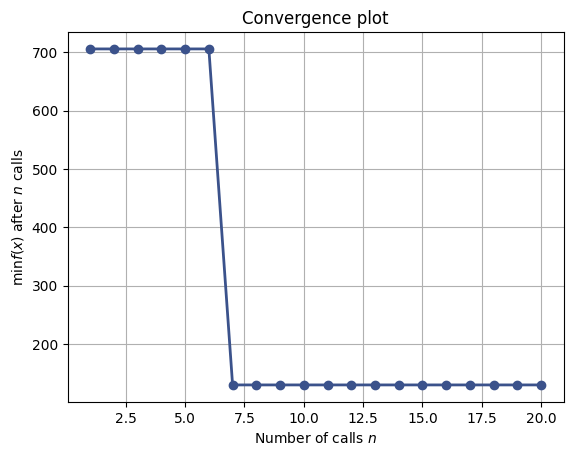

In [35]:
# Define the search space - range of values for each parameter
#TODO: edit the ranges for this
space = [Real(250.0, 250.1, name='p0'),
         Real(-20.0, 20.0, name='p1'),
        Real(-20.0, 20.0, name='p2'),
        Real(-20.0, 20.0, name='p3'),
        Real(-20.0, 20.0, name='p4'),
        Real(-20.0, 20.0, name='p5'),
        Real(-20.0, 20.0, name='p6'),
        Real(-1e-10, 1e-10, name='p7'),
        Real(-1e-10, 1e-10, name='p8'),
        Real(-100.0, 100.0, name='p9'),
        Real(-20.0, 20.0, name='p10'),
        Real(-20.0, 20.0, name='p11'),
        Real(-1e-10, 1e-10, name='p12'),
        Real(-1e-10, 1e-10, name='p13'),
        Real(-20.0, 20.0, name='p14'),
        Real(-1e-10, 1e-10, name='p15'),
        Real(-1e-10, 1e-10, name='p16'),
        Real(-1e-10, 1e-10, name='p17'),
        Real(-20.0, 20.0, name='p18')]

# Perform Bayesian Optimization
result = gp_minimize(diffPacejka,      # The function to minimize
                     space,                   # The search space
                     n_calls=20,              # The number of evaluations
                     random_state=42)         # Random state for reproducibility
P = result.x
remove_small_data(P)
P_previous = [250, 1.4, 2.4, -0.25, 3, -0.1, -1.5, 0, 0, -30.5, 1.15, 1, 0, 0, -0.128, 0, 0, 0, 1.43]
# Print the best parameters and the corresponding minimum value
print(f"Best parameters: {P}")
print(f"Previous parameters: {P_previous}")
print("Minimum value: {:.4f}".format(result.fun))

# Plot convergence
plot_convergence(result)